In [10]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

To run a set of benchmarks we'll want to run:
```
cd ~/sophgo/smokewagon-benchmarks
gcc microbenchmark-mmap.c
./a.out -t 64
./a.out -t 64 -s
./a.out -t 64 -f
./a.out -t 64 -s -f
```

In [ ]:
import subprocess

result = subprocess.run([
    "scp milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/result-* ~/sophgo/smokewagon-benchmarks/"],
    capture_output=True, text=True, shell=True, check=True)
print(result.stdout)

In [2]:
from pathlib import Path

hash_names = {
    "9010837790f5dd87f0a043510e5cb293bb3f16d2" : "xarray-fixed",
    "e996d506d9c8f534dd32edcf5139ba3aaee48b19" : "add-fork",
    "24ac9404254c0ee7cccd53821e73af8c81fb9a46" : "xarray-bug", # this version wasn't deallocating unused smokewagon masks
    "c277100ed866fc7f3cfae0b6172c5d3ed2ab5bb0" : "flat1GB",
    "eadff10a39c6faf2e486ed108e3a3bc4c2bb77b3" : "baseline",
}

import pandas as pd
import matplotlib.pyplot as plt

prefix = "result-microbenchmark-mmap-"
suffix = ".csv"
result_files = Path("~/sophgo/smokewagon-benchmarks").expanduser().glob(prefix + "*" + suffix)
dfs = []

for f in result_files:
    df = pd.read_csv(f, index_col=0)

    # column name faff
    label = f.name[len(prefix):-len(suffix)].split("-")
    #print(label)
    col_label = tuple( [ label[1], label[0], label[2], hash_names.get(label[3]) ] )
    #print(col_label)
    df.columns = pd.MultiIndex.from_tuples([col_label], names=['benchmark','filtering','bystander','version'])
    #print(df)
    dfs.append(df)

df = pd.concat(dfs, axis=1) 

duration = 30 # just have to remember this for now
df = df.reindex(sorted(df.columns), axis=1) / duration # sorting columns now helps keep consistency in plotting later
df.to_csv('smokewagon-microbenchmark-results.csv')
df

benchmark    filebacked                                            \
filtering      inactive                                             
bystander   noBystander                                             
version        add-fork      baseline       flat1GB    xarray-bug   
threads                                                             
1          63754.600000  29893.433333  27997.400000  29399.700000   
2          19323.633333  18714.900000  17601.300000  17804.733333   
3          18923.300000  17398.833333  16323.900000  16667.266667   
4          17262.500000  16124.400000  15092.833333  15293.033333   
5          15631.733333  16141.800000  15146.233333  15328.966667   
...                 ...           ...           ...           ...   
60          6186.433333   6292.366667   6157.333333   6163.600000   
61          6144.666667   6255.400000   6112.233333   6123.133333   
62          6065.566667   6181.366667   6033.733333   6047.166667   
63          5966.633333   6076.066667   5942.433333   5950.333333   
64          5884.400000   5988.666667   5856.133333   5859.366667   

benchmark                                                          \
filtering                                                           
bystander                yesBystander                               
version    xarray-fixed      add-fork      baseline       flat1GB   
threads                                                             
1          61855.700000  28530.166667  30661.033333  26590.800000   
2          18618.300000  17811.466667  18953.833333  17190.600000   
3          18511.266667  16553.866667  17179.466667  16107.200000   
4          16447.033333  15515.600000  16179.066667  14917.800000   
5          15378.500000  15410.166667  16131.900000  14987.800000   
...                 ...           ...           ...           ...   
60          6129.766667   6187.733333   6307.000000   6159.333333   
61          6105.800000   6146.833333   6277.066667   6108.333333   
62          6003.166667   6065.800000   6187.033333   6032.933333   
63          5926.366667   5975.233333   6101.900000   5945.500000   
64          5830.400000   5888.766667   6001.433333   5845.366667   

benchmark                              ...     membacked                \
filtering                              ...    smokewagon                 
bystander                              ...   noBystander                 
version      xarray-bug  xarray-fixed  ...      add-fork      baseline   
threads                                ...                               
1          29620.966667  26146.866667  ...   7440.333333  15338.966667   
2          18185.500000  15968.700000  ...  12576.266667  13169.400000   
3          16633.500000  12722.033333  ...  10097.233333  11701.600000   
4          15460.133333  14403.000000  ...   9681.533333  10935.600000   
5          15471.633333  12690.000000  ...   8918.533333  11072.100000   
...                 ...           ...  ...           ...           ...   
60          6163.500000   6172.033333  ...   8427.933333   5167.800000   
61          6128.366667   6129.033333  ...   8410.433333   5147.900000   
62          6051.066667   6047.600000  ...   8307.766667   5091.733333   
63          5961.166667   5949.633333  ...   8408.800000   5032.133333   
64          5874.366667   5862.600000  ...   8371.600000   4971.000000   

benchmark                                                          \
filtering                                                           
bystander                                            yesBystander   
version         flat1GB    xarray-bug  xarray-fixed      add-fork   
threads                                                             
1          19504.933333   7524.766667  11386.933333   7609.133333   
2          24077.966667  12494.833333  10746.100000  12771.933333   
3          37769.900000  10328.966667  10427.233333  10242.933333   
4          38335.100000  10383.066667  10733.500000  

In [3]:
df.unstack().unstack()

threads                                                    1             2   \
benchmark  filtering  bystander    version                                    
filebacked inactive   noBystander  add-fork      63754.600000  19323.633333   
                                   baseline      29893.433333  18714.900000   
                                   flat1GB       27997.400000  17601.300000   
                                   xarray-bug    29399.700000  17804.733333   
                                   xarray-fixed  61855.700000  18618.300000   
                      yesBystander add-fork      28530.166667  17811.466667   
                                   baseline      30661.033333  18953.833333   
                                   flat1GB       26590.800000  17190.600000   
                                   xarray-bug    29620.966667  18185.500000   
                                   xarray-fixed  26146.866667  15968.700000   
           smokewagon noBystander  add-fork      11997.500000  21001.400000   
                                   baseline      31675.466667  19005.366667   
                                   flat1GB       58686.600000  89592.733333   
                                   xarray-bug    11762.233333  19502.666667   
                                   xarray-fixed  20145.433333  13212.900000   
                      yesBystander add-fork      11765.033333  20957.033333   
                                   baseline      31584.833333  18974.866667   
                                   flat1GB       57936.933333  88692.766667   
                                   xarray-bug    11528.666667  18974.300000   
                                   xarray-fixed  19804.366667  12987.200000   
membacked  inactive   noBystander  add-fork      14450.000000  12644.433333   
                                   baseline      15153.900000  13238.900000   
                                   flat1GB       20742.033333  13070.133333   
                                   xarray-bug    14424.766667  12743.266667   
                                   xarray-fixed  21063.166667  13322.066667   
                      yesBystander add-fork      21104.666667  13407.066667   
                                   baseline      15082.533333  13181.400000   
                                   flat1GB       14140.366667  12495.300000   
                                   xarray-bug    14496.766667  12879.200000   
                                   xarray-fixed  14663.633333  12767.633333   
           smokewagon noBystander  add-fork       7440.333333  12576.266667   
                                   baseline      15338.966667  13169.400000   
                                   flat1GB       19504.933333  24077.966667   
                                   xarray-bug     7524.766667  12494.833333   
                                   xarray-fixed  11386.933333  10746.100000   
                      yesBystander add-fork       7609.133333  12771.933333   
                                   baseline      15185.400000  13350.966667   
                                   flat1GB       19736.633333  35732.300000   
                                   xarray-bug     7235.400000  12390.900000   
                                   xarray-fixed  10845.533333  10586.333333   

threads                                                    3             4   \
benchmark  filtering  bystander    version                                    
filebacked inactive   noBystander  add-fork      18923.300000  17262.500000   
                                   baseline      17398.833333  16124.400000   
                                   flat1GB       16323.900000  15092.833333   
                                   xarray-bug    16667.266667  15293.033333   
                                   xarray-fixed  18511.266667  16447.033333   
                      yesBystander add-fork      16553.866667  15515.600000   
                                   baseline      

In [4]:
mask = (
    (df.columns.get_level_values(0) == "filebacked") &
    (
        (df.columns.get_level_values(1) == "smokewagon") |
        (
            (df.columns.get_level_values(1) == "inactive") &
            (df.columns.get_level_values(2) == "baseline")
        )
    )
)

subset = df.loc[:, mask]
subset

benchmark    filebacked                                            \
filtering    smokewagon                                             
bystander   noBystander                                             
version        add-fork      baseline       flat1GB    xarray-bug   
threads                                                             
1          11997.500000  31675.466667  58686.600000  11762.233333   
2          21001.400000  19005.366667  89592.733333  19502.666667   
3          14494.766667  17569.666667  59011.066667  14724.533333   
4          14018.733333  16205.233333  60988.600000  13345.566667   
5          13915.033333  16461.600000  59199.966667  13016.466667   
...                 ...           ...           ...           ...   
60         12959.200000   6313.866667  56561.833333  13095.533333   
61         13145.033333   6279.200000  56531.800000  12812.033333   
62         13103.633333   6200.966667  56496.066667  13056.966667   
63         13022.066667   6099.366667  56274.000000  12941.633333   
64         13118.866667   6018.233333  56371.166667  13093.700000   

benchmark                                                          \
filtering                                                           
bystander                yesBystander                               
version    xarray-fixed      add-fork      baseline       flat1GB   
threads                                                             
1          20145.433333  11765.033333  31584.833333  57936.933333   
2          13212.900000  20957.033333  18974.866667  88692.766667   
3          13520.833333  14692.066667  17361.433333  67636.033333   
4          13073.833333  14657.366667  16243.466667  62139.333333   
5          13453.200000  14455.900000  16395.300000  61570.033333   
...                 ...           ...           ...           ...   
60         14315.833333  13066.200000   6310.966667  56808.733333   
61         14349.200000  13133.000000   6274.466667  56789.200000   
62         14233.533333  13109.166667   6195.433333  56853.100000   
63         14304.933333  13047.666667   6100.033333  56737.266667   
64         14215.533333  13124.933333   6002.400000  56467.233333   

benchmark                              
filtering                              
bystander                              
version      xarray-bug  xarray-fixed  
threads                                
1          11528.666667  19804.366667  
2          18974.300000  12987.200000  
3          14644.233333  14051.133333  
4          14640.966667  14544.233333  
5          14393.666667  14737.966667  
...                 ...           ...  
60         12953.166667  14359.633333  
61         13014.933333  14216.566667  
62         13142.566667  14292.166667  
63         13000.433333  14293.433333  
64         13064.500000  14256.033333  

[64 rows x 10 columns]

In [5]:
cmap = plt.get_cmap("Dark2")
color_keys = df.columns.droplevel(0).unique()
colors = {key: cmap(i % 8) for i, key in enumerate(color_keys)}

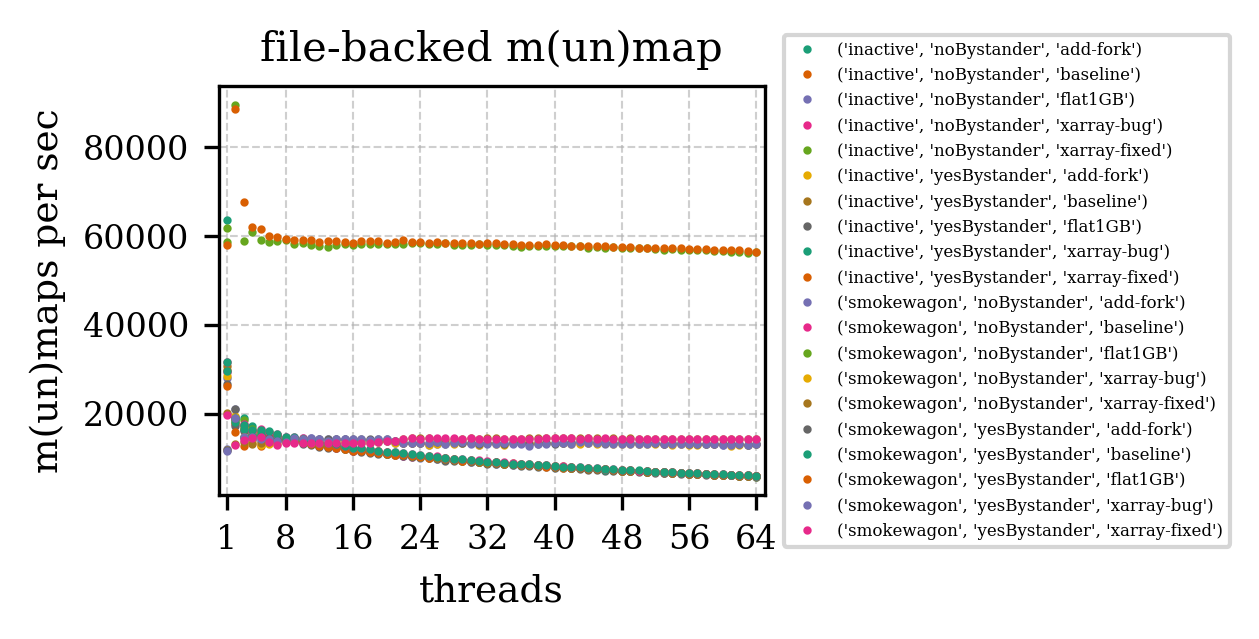

In [6]:
mask = df.columns.get_level_values(0) == "filebacked"
subset = df.loc[:, mask]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(4.3, 2.2))  # ACM single-column width is about (3.3, 2.2)
for col in subset.columns:
    ax.plot(
        subset.index,
        subset[col],
        '.',
        markersize=2,
        color=colors[col[1:]],
        label=str(col)
    )
ax.set_title("file-backed m(un)map")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps per sec")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(subset.columns.droplevel([0]), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=4)
plt.tight_layout()
#plt.savefig("microbenchmark-mmap-filebacked.pdf", bbox_inches="tight")

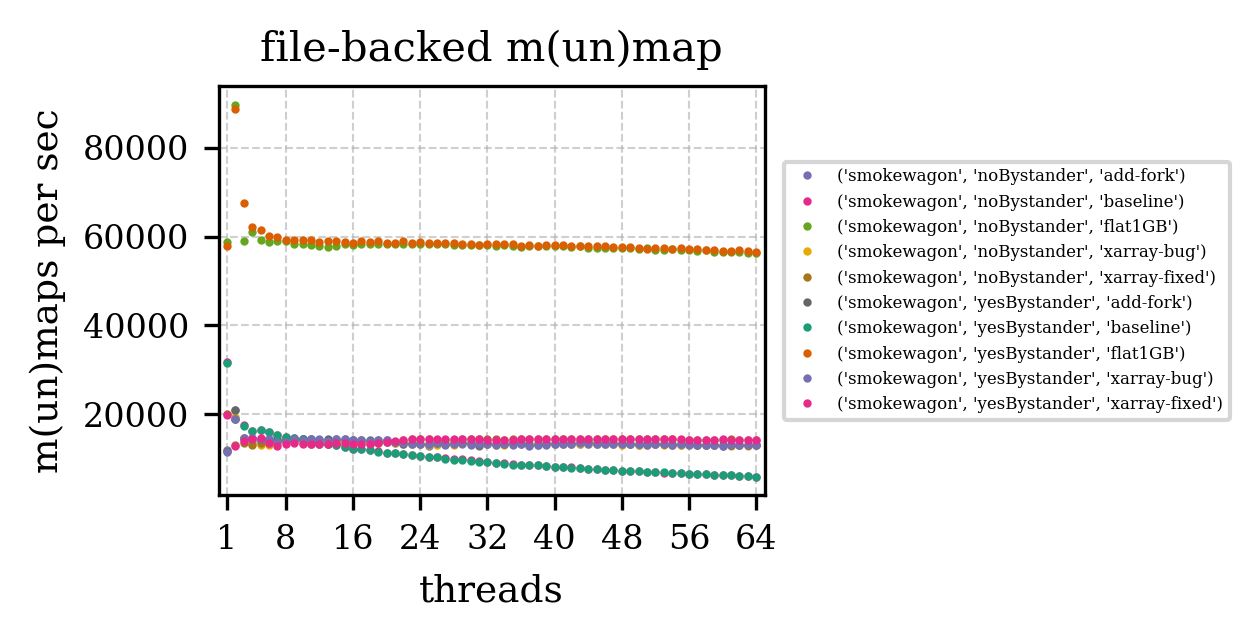

In [7]:
mask = (
    (df.columns.get_level_values(0) == "filebacked") &
    (
        (df.columns.get_level_values(1) == "smokewagon") |
        (
            (df.columns.get_level_values(1) == "inactive") &
            (df.columns.get_level_values(2) == "baseline")
        )
    )
)
subset = df.loc[:, mask]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(4.3, 2.2))  # ACM single-column width is about (3.3, 2.2)
for col in subset.columns:
    ax.plot(
        subset.index,
        subset[col],
        '.',
        markersize=2,
        color=colors[col[1:]],
        label=str(col)
    )
ax.set_title("file-backed m(un)map")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps per sec")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(subset.columns.droplevel([0]), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=4)
plt.tight_layout()
plt.savefig("microbenchmark-mmap-filebacked.pdf", bbox_inches="tight")

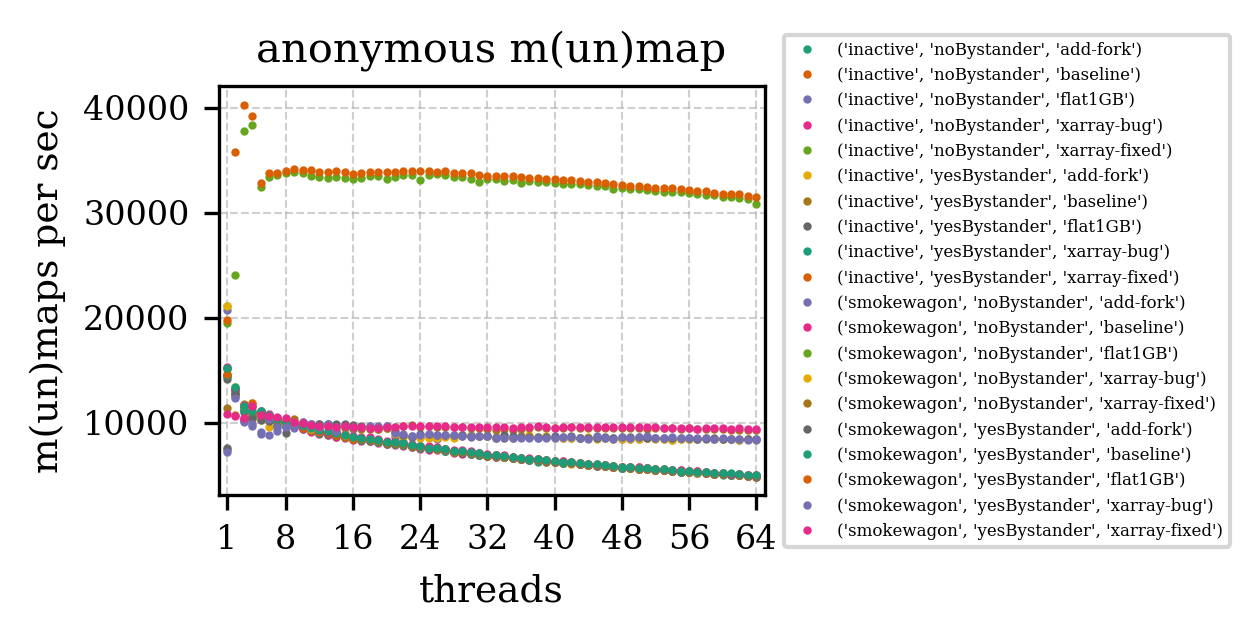

In [8]:
mask = df.columns.get_level_values(0) == "membacked"
subset = df.loc[:, mask]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(4.3, 2.2))  # ACM single-column width is about (3.3, 2.2)
for col in subset.columns:
    ax.plot(
        subset.index,
        subset[col],
        '.',
        markersize=2,
        color=colors[col[1:]],
        label=str(col)
    )
ax.set_title("anonymous m(un)map")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps per sec")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(subset.columns.droplevel([0]), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=4)
plt.tight_layout()
#plt.savefig("microbenchmark-mmap-membacked.pdf", bbox_inches="tight")

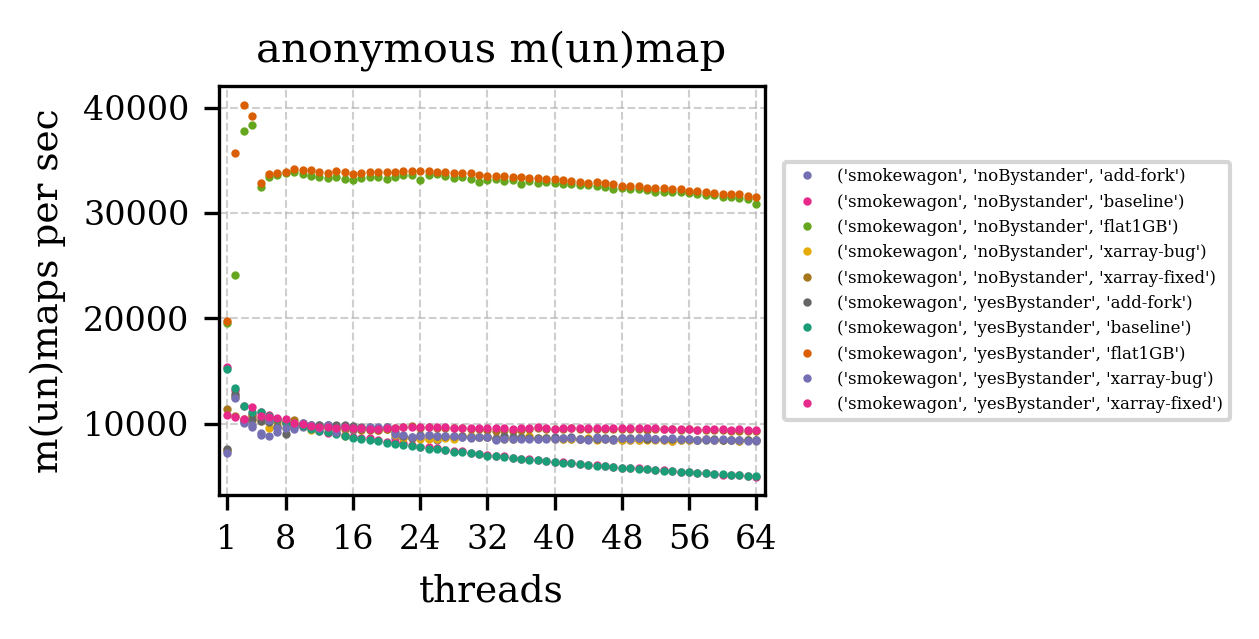

In [9]:
mask = (
    (df.columns.get_level_values(0) == "membacked") &
    (
        (df.columns.get_level_values(1) == "smokewagon") |
        (
            (df.columns.get_level_values(1) == "inactive") &
            (df.columns.get_level_values(2) == "baseline")
        )
    )
)
subset = df.loc[:, mask]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(4.3, 2.2))  # ACM single-column width is about (3.3, 2.2)
for col in subset.columns:
    ax.plot(
        subset.index,
        subset[col],
        '.',
        markersize=2,
        color=colors[col[1:]],
        label=str(col)
    )
ax.set_title("anonymous m(un)map")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps per sec")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(subset.columns.droplevel([0]), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=4)
plt.tight_layout()
plt.savefig("microbenchmark-mmap-membacked.pdf", bbox_inches="tight")